# Bài Ôn Tập

### 1.  (2 điểm) Viết mạ để đọc dữ liệu và tìm hiểu thông tin về dữ liệu:

a.  Dữ liệu có bao nhiêu chim cánh cụt. Số lượng mỗi loại

b.  Thể  hiện  các  thông  số  thống  kê  cơ  bản  của  từng  thuộc  tính  thông  qua  hàm 
describe(). Dựa vào kết quả  bạn hãy  đưa ra bình luận trên thuộc tính trọng 
lượng (body_mass_g)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10,6)

df = pd.read_csv('penguins-data.csv')
print(f"Dữ liệu: {df.shape[0]} dòng x {df.shape[1]} cột")
df.head(10)

Dữ liệu: 333 dòng x 8 cột


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
5,6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
6,7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
7,12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,FEMALE
8,13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,MALE
9,14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,MALE


In [9]:
print("Số lượng chim cánh cụt trong dữ liệu là:", len(df))

Số lượng chim cánh cụt trong dữ liệu là: 333


In [10]:
countSpecies = df["species"].value_counts()
print(countSpecies)

Adelie       146
Gentoo       119
Chinstrap     68
Name: species, dtype: int64


In [12]:
countSpeciesIsland = df.groupby("island")["species"].value_counts()
print(countSpeciesIsland)

island     species  
Biscoe     Gentoo       119
           Adelie        44
Dream      Chinstrap     68
           Adelie        55
Torgersen  Adelie        47
Name: species, dtype: int64


In [ ]:
# c. Với mỗi loại chim cánh cụt, bạn hãy so sánh các đại lượng thống kê: 
# giá trị trung bình, trung vị, độ lệch chuẩn trên các thuộc tính độ dài mỏ
# (bill_leghth_mm), độ sâu mỏ (bill_depth_mm), độ dài cánh (flipper) và trọng
# lượng (body_mass)


In [29]:
# giá trị trung bình mỗi loại chim cánh cụt
print()
resultGentoo = df.groupby("species")[["bill_length_mm","bill_depth_mm", "flipper_length_mm", "body_mass_g"]].agg(["mean", "median", "std"])
print(resultGentoo.to_string())

print("Loài ")


          bill_length_mm                  bill_depth_mm                  flipper_length_mm                   body_mass_g                    
                    mean median       std          mean median       std              mean median       std         mean  median         std
species                                                                                                                                     
Adelie         38.823973  38.85  2.662597     18.347260  18.40  1.219338        190.102740  190.0  6.521825  3706.164384  3700.0  458.620135
Chinstrap      48.833824  49.55  3.339256     18.420588  18.45  1.135395        195.823529  196.0  7.131894  3733.088235  3700.0  384.335081
Gentoo         47.568067  47.40  3.106116     14.996639  15.00  0.985998        217.235294  216.0  6.585431  5092.436975  5050.0  501.476154
Loài 


### 2.  (4 điểm) Khảo sát thuộc tính trọng lượng (body_mass_g) 

a.  Vẽ biểu đồ cho biết phân phối của trọng lượng của những chim cánh cụt trong 
bộ dữ liệu

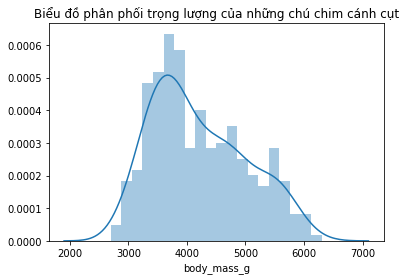

In [36]:
sns.distplot(df["body_mass_g"], bins= 20, kde=True)
plt.title("Biểu đồ phân phối trọng lượng của những chú chim cánh cụt")
plt.show()

b.  Vẽ biểu đồ so sánh trọng lượng của ba loại chim cánh cụt



species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64


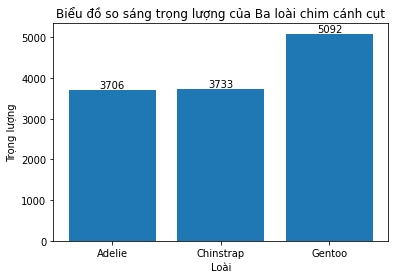

In [48]:
getData = df.groupby("species")["body_mass_g"].mean()
print(getData)
bars = plt.bar(getData.index, getData.values)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height), ha='center', va='bottom')


plt.title("Biểu đồ so sáng trọng lượng của Ba loài chim cánh cụt")
plt.xlabel("Loài")
plt.ylabel("Trọng lượng")
plt.show()

c.  Theo bạn thuộc tính định lượng nào có khả năng có mối tương quan tuyến tính 
với thuộc tính định lượng 



In [49]:
df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


d.  Lựa  chọn  thuộc  tính  có  mối  tương  quan  tuyến  tính  cao  nhất  với  thuộc  tính 
trọng lượng. Bạn hãy xây dựng mô hình  hồi quy tuyến tính  đơn giản  để  dự
đoán trọng lượng chim cánh cụt dựa trên thuộc tính này. Viết hàm hồi quy tìm 
được.

### 3.  (4  điểm)  Giả  sử  bộ  dữ  liệu  được cung cấp là một mẫu  thống kê. Bạn hãy thực hiện một số ước lượng sau liên quan đến loài chim cánh cụt Gentoo

a.  Ước lượng tỷ lệ loài chim cánh cụt Gentoo.



b.  Ước lượng trọng lượng của của loài chim cánh cụt Gentoo.